In [2]:
# Для анализа и разметки данных
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from PIL import Image, ImageOps
from IPython.display import display, clear_output
import csv
import random
from sklearn.preprocessing import StandardScaler

# Для обучения RankNet
import wandb
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

In [3]:
wandb.login() # вставить API ключ от аккаунта W&B

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

  2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

  ········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: rimedheart (rimedheart-personal-use) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [7]:
features_df = pd.read_csv('/kaggle/input/datasets/neuromant/ranknet-dataset-206-imgs/building_features_206.csv')
features_df['building_name'] = features_df['building_name'].astype(str)
features_df.set_index('building_name', inplace=True)

# Нормализация 
scaler = StandardScaler()
scaled_values = scaler.fit_transform(features_df.values)
features_df_scaled = pd.DataFrame(scaled_values, index=features_df.index, columns=features_df.columns)
class PairwiseDataset(Dataset):
    def __init__(self, pairs_df, features_df_scaled, session_name):
        self.features_a, self.features_b, self.labels = [], [], []
        feature_cols = [f"{session_name}_mean", f"{session_name}_max", f"{session_name}_prevalence"]
        
        for _, row in pairs_df.iterrows():
            img_a, img_b, winner = str(row['image_a']), str(row['image_b']), str(row['winner'])
            if winner not in ['0', '1', '2']: continue
            if img_a not in features_df_scaled.index or img_b not in features_df_scaled.index: continue
                
            # Берем нормализованные векторы
            vec_a = features_df_scaled.loc[img_a, feature_cols].values.astype(np.float32)
            vec_b = features_df_scaled.loc[img_b, feature_cols].values.astype(np.float32)
            
            label = 1.0 if winner == '0' else (0.0 if winner == '1' else 0.5)
            self.features_a.append(vec_a)
            self.features_b.append(vec_b)
            self.labels.append(label)
            
        self.features_a = np.array(self.features_a)
        self.features_b = np.array(self.features_b)
        self.labels = np.array(self.labels, dtype=np.float32)
    def __len__(self): return len(self.labels)
    def __getitem__(self, idx):
        return torch.tensor(self.features_a[idx]), torch.tensor(self.features_b[idx]), torch.tensor(self.labels[idx])

In [8]:
class RankNetHead(nn.Module):
    def __init__(self, input_dim=3, hidden_dim=8):
        super(RankNetHead, self).__init__()
        self.scorer = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1)
        )
    def forward(self, x_a, x_b): return self.scorer(x_a) - self.scorer(x_b)
    def predict_score(self, x): return torch.sigmoid(self.scorer(x))

SESSIONS = ['coating_deterioration', 'cracks', 'masonry_degradation', 'moisture_bio_damage', 'vandalism']
trained_models = {}

for session in SESSIONS:
    pairs_file = f'/kaggle/input/datasets/neuromant/ranknet-dataset-206-imgs/ranking_pairs_{session}.csv'
    if not os.path.exists(pairs_file): continue
        
    pairs_df = pd.read_csv(pairs_file)
    dataset = PairwiseDataset(pairs_df, features_df_scaled, session)
    if len(dataset) < 10: continue
        
    dataloader = DataLoader(dataset, batch_size=16, shuffle=True)
    
    model = RankNetHead(input_dim=3, hidden_dim=8)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.01) 
    
    # Инициализируем отдельный W&B проект на каждую сессию   
    wandb.init(project="facades-damage-ranking", name=f"run_{session}", reinit=True)
    
    print(f"\n--- Обучение: {session.upper()} (пар: {len(dataset)}) ---")
    EPOCHS = 100
    for epoch in range(EPOCHS):
        total_loss, correct_pairs, total_pairs = 0.0, 0, 0
        
        for vec_a, vec_b, labels in dataloader:
            optimizer.zero_grad()
            diff_scores = model(vec_a, vec_b).squeeze()
            
            loss = criterion(diff_scores, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            
            # Расчет Accuracy
            # Игнорируем метки 0.5 (одинаково) при расчете точности для простоты
            with torch.no_grad():
                preds = (diff_scores > 0).float()
                mask = (labels != 0.5)
                correct_pairs += (preds[mask] == labels[mask]).sum().item()
                total_pairs += mask.sum().item()
                
        epoch_loss = total_loss / len(dataloader)
        epoch_acc = (correct_pairs / total_pairs) if total_pairs > 0 else 0.0
        
        # Логируем в Wandb
        wandb.log({"epoch": epoch, "loss": epoch_loss, "accuracy": epoch_acc})
            
        if (epoch+1) % 10 == 0:
            print(f"Epoch {epoch+1}/{EPOCHS}, Loss: {epoch_loss:.4f}, Accuracy: {epoch_acc:.2%}")
            
    model.eval()
    trained_models[session] = model
    wandb.finish() # Закрываем запуск сессии

print("\nОбучение завершено!")


wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.



--- Обучение: COATING_DETERIORATION (пар: 103) ---
Epoch 10/100, Loss: 0.4362, Accuracy: 78.79%
Epoch 20/100, Loss: 0.4383, Accuracy: 80.81%
Epoch 30/100, Loss: 0.4284, Accuracy: 80.81%
Epoch 40/100, Loss: 0.4531, Accuracy: 80.81%
Epoch 50/100, Loss: 0.4218, Accuracy: 79.80%
Epoch 60/100, Loss: 0.3999, Accuracy: 82.83%
Epoch 70/100, Loss: 0.4171, Accuracy: 81.82%
Epoch 80/100, Loss: 0.3906, Accuracy: 83.84%
Epoch 90/100, Loss: 0.3851, Accuracy: 84.85%
Epoch 100/100, Loss: 0.4285, Accuracy: 82.83%


accuracy,▁▄▄▄▅▅▅▅▅▅▅▅▅▅▅▅▅▅▆▆▆▆▇▇▇▆▆▆▆▆▇▇█▇██▇▇█▇
epoch,▁▁▁▂▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▅▆▆▆▆▆▆▆▇▇▇▇█
loss,█▇▄▃▄▃▄▄▃▄▃▃▄▃▃▃▄▃▄▄▂▂▂▂▃▂▃▂▁▃▁▃▃▂▂▁▃▂▁▃
accuracy,0.82828
epoch,99
loss,0.42854



--- Обучение: CRACKS (пар: 52) ---
Epoch 10/100, Loss: 0.6261, Accuracy: 82.00%
Epoch 20/100, Loss: 0.4684, Accuracy: 82.00%
Epoch 30/100, Loss: 0.4909, Accuracy: 82.00%
Epoch 40/100, Loss: 0.4415, Accuracy: 82.00%
Epoch 50/100, Loss: 0.4847, Accuracy: 82.00%
Epoch 60/100, Loss: 0.4878, Accuracy: 82.00%
Epoch 70/100, Loss: 0.5281, Accuracy: 84.00%
Epoch 80/100, Loss: 0.4816, Accuracy: 84.00%
Epoch 90/100, Loss: 0.4512, Accuracy: 84.00%
Epoch 100/100, Loss: 0.4269, Accuracy: 84.00%


accuracy,▁▂▅▆████████████████████████████████████
epoch,▁▁▁▁▂▂▂▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▅▆▆▆▆▆▆▆▆▇▇▇▇▇███
loss,█▇▆▆▄▂▄▂▃▂▂▂▃▄▃▃▂▃▁▁▃▂▁▂▃▂▂▂▄▃▃▄▂▃▂▂▃▂▁▁
accuracy,0.84
epoch,99
loss,0.42692


...


--- Обучение: MOISTURE_BIO_DAMAGE (пар: 111) ---
Epoch 10/100, Loss: 0.5074, Accuracy: 73.87%
Epoch 20/100, Loss: 0.4790, Accuracy: 75.68%
Epoch 30/100, Loss: 0.4659, Accuracy: 75.68%
Epoch 40/100, Loss: 0.4599, Accuracy: 76.58%
Epoch 50/100, Loss: 0.4589, Accuracy: 76.58%
Epoch 60/100, Loss: 0.4515, Accuracy: 77.48%
Epoch 70/100, Loss: 0.4484, Accuracy: 78.38%
Epoch 80/100, Loss: 0.4485, Accuracy: 79.28%
Epoch 90/100, Loss: 0.4466, Accuracy: 79.28%
Epoch 100/100, Loss: 0.4443, Accuracy: 79.28%


accuracy,▁▃▂▂▃▅▆▆▆▆▄▄▄▃▄▄▄▄▄▅▅▆▆▆▆▆▇█▇▆▇▇▇▇▇▇▆▇▇▇
epoch,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇█████
loss,█▆▆▆▄▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▁▂▁▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁
accuracy,0.79279
epoch,99
loss,0.44434



--- Обучение: VANDALISM (пар: 50) ---
Epoch 10/100, Loss: 0.4336, Accuracy: 80.49%
Epoch 20/100, Loss: 0.3682, Accuracy: 80.49%
Epoch 30/100, Loss: 0.2593, Accuracy: 78.05%
Epoch 40/100, Loss: 0.3419, Accuracy: 80.49%
Epoch 50/100, Loss: 0.3304, Accuracy: 92.68%
Epoch 60/100, Loss: 0.3040, Accuracy: 92.68%
Epoch 70/100, Loss: 0.2118, Accuracy: 92.68%
Epoch 80/100, Loss: 0.2757, Accuracy: 92.68%
Epoch 90/100, Loss: 0.2810, Accuracy: 97.56%
Epoch 100/100, Loss: 0.1919, Accuracy: 97.56%


accuracy,▁▆▇▇▇▇▇▇▇▇▇▆▆▆▆▆▇██████████▇▇█▇█████████
epoch,▁▁▁▁▁▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▅▅▆▆▆▆▇▇▇▇▇▇██
loss,█▆▄▃▃▃▃▂▂▃▂▂▂▂▂▂▂▃▂▂▂▂▃▁▂▂▁▂▃▄▁▁▃▂▁▁▂▁▂▂
accuracy,0.97561
epoch,99
loss,0.19188



Обучение завершено!


In [10]:
results = []

score_cols = [col for col in final_scores_df.columns if '_score' in col]

for b_name, row in features_df.iterrows():
    b_dict = {'building_name': b_name}
    
    for session, model in trained_models.items():
        feature_cols = [f"{session}_mean", f"{session}_max", f"{session}_prevalence"]
        
        # Берем вектор (1 батч, 3 фичи)
        vec = row[feature_cols].values.astype(np.float32)
        vec_tensor = torch.tensor(vec).unsqueeze(0) 
        
        with torch.no_grad():
            score = model.predict_score(vec_tensor).item()
            
        b_dict[f"{session}_score"] = score
        
    results.append(b_dict)

final_scores_df = pd.DataFrame(results)

# Нормализуем индивидуальные скоры от 0.0 до 1.0 (Min-Max Scaling)
for col in score_cols:
    min_val = final_scores_df[col].min()
    max_val = final_scores_df[col].max()
    
    # Защита от деления на ноль
    if max_val > min_val:
        final_scores_df[col] = (final_scores_df[col] - min_val) / (max_val - min_val)
    else:
        final_scores_df[col] = 0.0

# Теперь пересчитываем Глобальный Индекс на основе выровненных от 0 до 1 баллов
final_scores_df['Global_Damage_Index'] = final_scores_df[score_cols].mean(axis=1)


# Выводим Топ-10 самых "убитых"
final_scores_df.sort_values(by='Global_Damage_Index', ascending=False, inplace=True)
display(final_scores_df.head(10))

# Можно сохранить финал:
# final_scores_df.to_csv('../data/processed/buildings_damage_scores_ranked.csv', index=False)


,building_name,coating_deterioration_score,cracks_score,masonry_degradation_score,moisture_bio_damage_score,vandalism_score,Global_Damage_Index
96,DSC02223,0.274320,1.000000,0.477106,0.394048,0.829552,0.595005
200,49,0.714193,0.600702,0.436694,0.229014,0.851142,0.566349
193,DSC02200,0.566852,0.615059,0.436694,0.347504,0.851142,0.563450
160,DSC02210,0.650841,0.156598,0.732494,0.345689,0.875020,0.552128
37,32,0.931004,0.013725,0.441717,0.476654,0.851142,0.542848
101,DSC02207,0.254567,0.013725,0.621486,0.815292,1.000000,0.541014
102,IMG_20260317_113335801_HDR,0.734538,0.000000,0.895635,0.249795,0.822882,0.540570
5,IMG_20260318_131235096_HDR,0.372407,0.013725,0.436694,1.000000,0.851142,0.534794
155,DSC02178,0.228177,0.139293,0.579781,0.862779,0.851142,0.532234
136,14,0.440364,0.013725,0.741791,0.593558,0.851142,0.528116


,coating_deterioration_score,cracks_score,masonry_degradation_score,moisture_bio_damage_score,vandalism_score
count,207.000000,207.000000,207.000000,207.000000,207.000000
mean,0.311711,0.035931,0.442172,0.248379,0.824188
std,0.257260,0.096720,0.101746,0.197510,0.097581
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.098928,0.000000,0.436694,0.076519,0.830796
50%,0.244204,0.013725,0.436694,0.230719,0.851142
75%,0.483586,0.035571,0.450106,0.357321,0.851142
max,1.000000,1.000000,1.000000,1.000000,1.000000


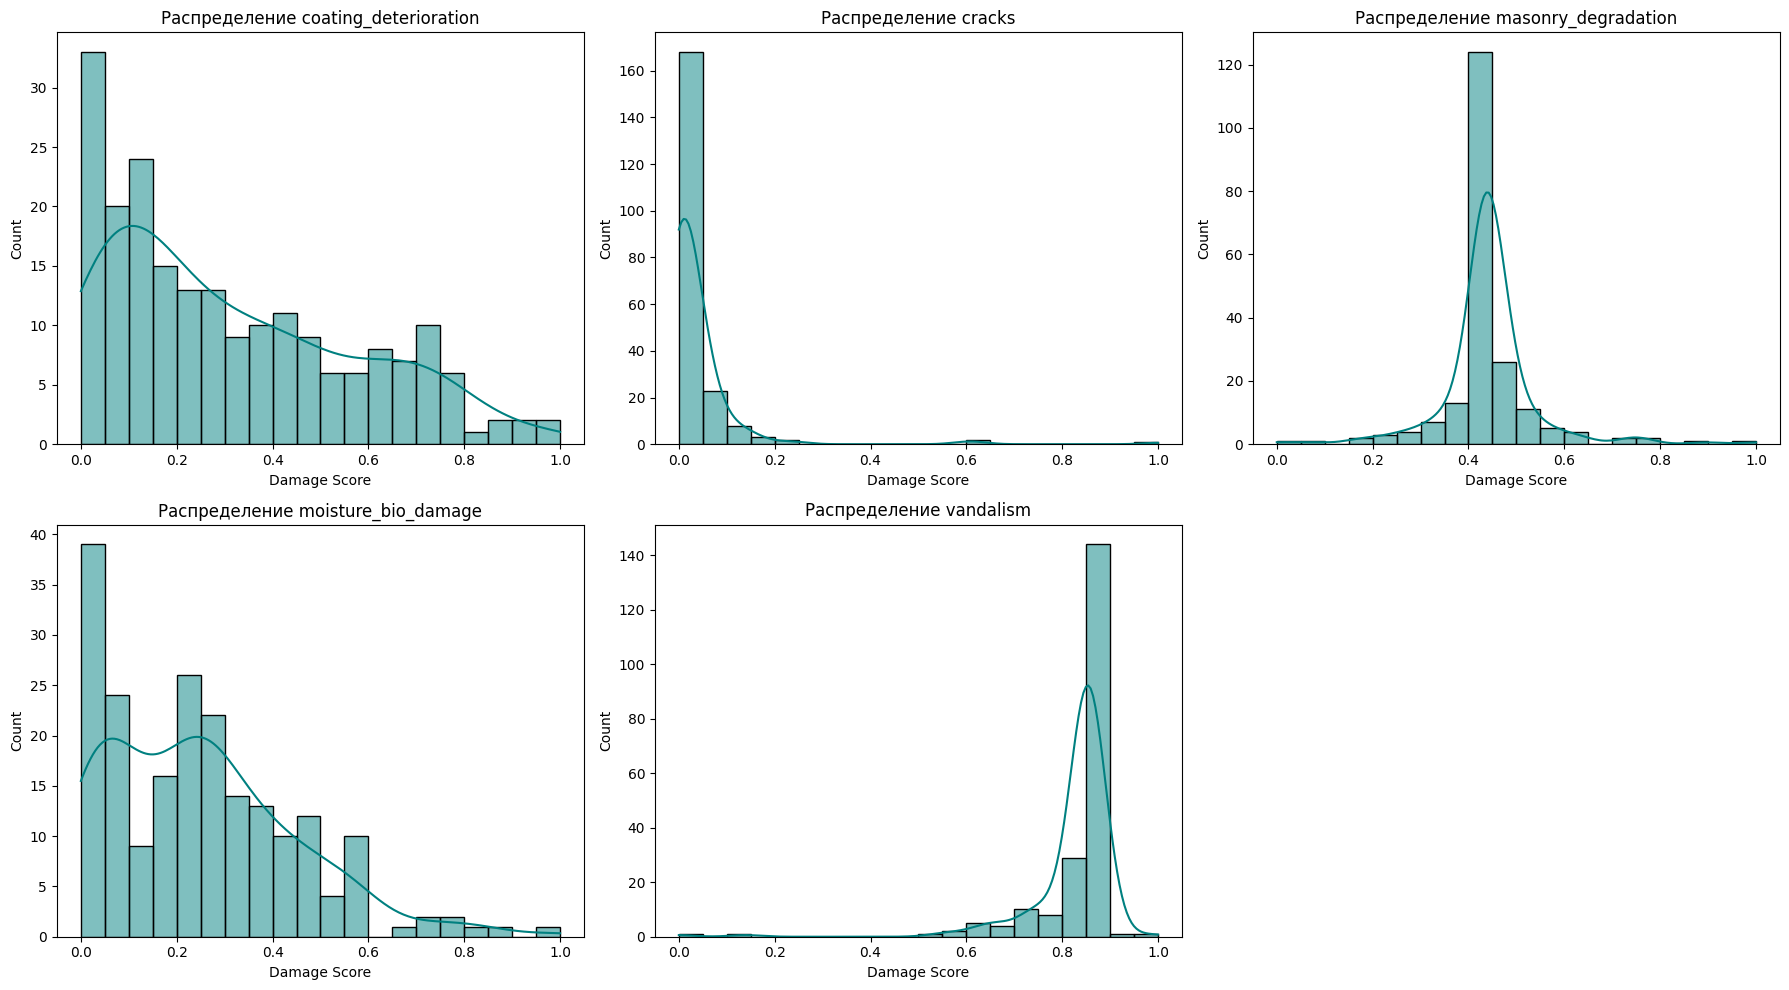

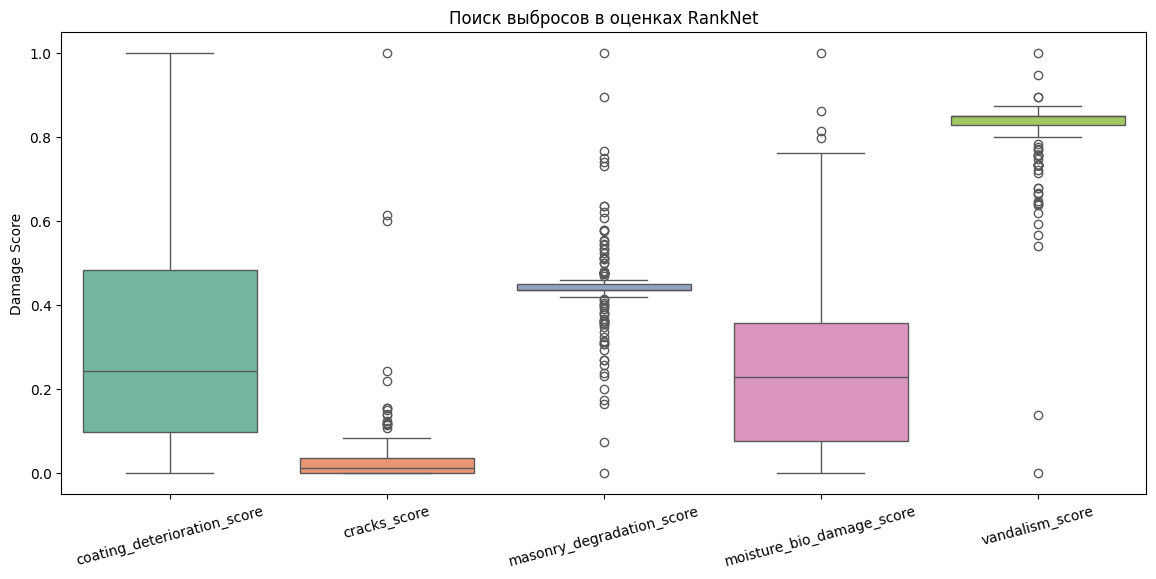

\Топ самых поврежденных зданий

Топ-5 худших по COATING_DETERIORATION:
 - Фасад: 77.jpg (Оценка RankNet: 1.000)
 - Фасад: 24.jpg (Оценка RankNet: 0.985)
 - Фасад: DSC02259.jpg (Оценка RankNet: 0.942)
 - Фасад: 32.jpg (Оценка RankNet: 0.931)
 - Фасад: DSC02476.jpg (Оценка RankNet: 0.863)

Топ-5 худших по CRACKS:
 - Фасад: DSC02223.jpg (Оценка RankNet: 1.000)
 - Фасад: DSC02200.jpg (Оценка RankNet: 0.615)
 - Фасад: 49.jpg (Оценка RankNet: 0.601)
 - Фасад: 29.jpg (Оценка RankNet: 0.244)
 - Фасад: DSC02399.jpg (Оценка RankNet: 0.220)

Топ-5 худших по MASONRY_DEGRADATION:
 - Фасад: DSC02250.jpg (Оценка RankNet: 1.000)
 - Фасад: IMG_20260317_113335801_HDR.jpg (Оценка RankNet: 0.896)
 - Фасад: IMG_20260319_121325656_HDR.jpg (Оценка RankNet: 0.767)
 - Фасад: DSC02312.jpg (Оценка RankNet: 0.752)
 - Фасад: 14.jpg (Оценка RankNet: 0.742)

Топ-5 худших по MOISTURE_BIO_DAMAGE:
 - Фасад: IMG_20260318_131235096_HDR.jpg (Оценка RankNet: 1.000)
 - Фасад: DSC02178.jpg (Оценка RankNet: 0.863)
 - Фасад: D

In [11]:
# Вывод статистик
display(final_scores_df[score_cols].describe())

# Распределения
plt.figure(figsize=(18, 10))
for i, col in enumerate(score_cols, 1):
    plt.subplot(2, 3, i)
    sns.histplot(final_scores_df[col], bins=20, kde=True, color='teal')
    plt.title(f'Распределение {col.replace("_score", "")}')
    plt.xlabel("Damage Score")
plt.tight_layout()
plt.show()

# Выбросы
# Попробуем понять, является ли супер-разрушенный фасад аномалией 
# или равномерно вписывается в общий тренд
plt.figure(figsize=(14, 6))
sns.boxplot(data=final_scores_df[score_cols], palette="Set2")
plt.xticks(rotation=15)
plt.title("Поиск выбросов в оценках RankNet")
plt.ylabel("Damage Score")
plt.show()

# Визуальное сопоставление (sanity check)
print("\Топ самых поврежденных зданий")
for col in score_cols:
    top_buildings = final_scores_df.nlargest(5, col)[['building_name', col]]
    clean_name = col.replace('_score', '').upper()
    print(f"\nТоп-5 худших по {clean_name}:")
    for _, row in top_buildings.iterrows():
        print(f" - Фасад: {row['building_name']}.jpg (Оценка RankNet: {row[col]:.3f})")


### Расчет Kendall's Tau

In [12]:
correct_pairs = 0
total_pairs = 0

with torch.no_grad():
    for vec_a, vec_b, labels in dataloader:
        diff_scores = model(vec_a, vec_b).squeeze()
        
        # Получаем бинарный прогноз сети (1: A хуже Б, 0: Б хуже А)
        preds = (diff_scores > 0).float()
        
        # Исключаем пары с ответом "одинаково" (target 0.5)
        mask = (labels != 0.5)
        
        correct_pairs += (preds[mask] == labels[mask]).sum().item()
        total_pairs += mask.sum().item()

# Попарная точность
accuracy = correct_pairs / total_pairs

# Метрика Кендалла (Kendall's Tau)
# Если Accuracy 0.85, то согласовано 85% пар, не согласовано 15%.
# Tau = 0.85 - 0.15 = 0.70
kendall_tau = (correct_pairs - (total_pairs - correct_pairs)) / total_pairs

print(f"Accuracy: {accuracy:.2%}")
print(f"Kendall's Tau: {kendall_tau:.3f}")

Accuracy: 97.56%
Kendall's Tau: 0.951
